In [19]:
import sklearn.datasets as sk
import pandas as pd

data = sk.load_breast_cancer()
df = pd.DataFrame(data=data.data,columns=data.feature_names)
df["target"] = data.target
df = df[df.columns[df.dtypes != "object"]]
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
import numpy as np

np.random.seed(48)
numrow = df[df.target == 1].count().iloc[0]
test_df = df[df.target == 0].iloc[np.random.randint(0,100,size=3),:]
test_df = pd.concat([test_df, df[df.target == 1].iloc[np.random.randint(0,100,size=3),:]])
test_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.990,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.71190,0.26540,0.4601,0.11890,0
72,17.200,24.52,114.20,929.4,0.10710,0.18300,0.16920,0.07944,0.1927,0.06487,...,33.82,151.60,1681.0,0.1585,0.7394,0.65660,0.18990,0.3313,0.13390,0
141,16.110,18.05,105.10,813.0,0.09721,0.11370,0.09447,0.05943,0.1861,0.06248,...,25.27,129.00,1233.0,0.1314,0.2236,0.28020,0.12160,0.2792,0.08158,0
151,8.219,20.70,53.27,203.9,0.09405,0.13050,0.13210,0.02168,0.2222,0.08261,...,29.72,58.08,249.8,0.1630,0.4310,0.53810,0.07879,0.3322,0.14860,1
188,11.810,17.39,75.27,428.9,0.10070,0.05562,0.02353,0.01553,0.1718,0.05780,...,26.48,79.57,489.5,0.1356,0.1000,0.08803,0.04306,0.3200,0.06576,1
116,8.950,15.76,58.74,245.2,0.09462,0.12430,0.09263,0.02308,0.1305,0.07163,...,17.07,63.34,270.0,0.1179,0.1879,0.15440,0.03846,0.1652,0.07722,1


In [88]:
from scipy.spatial.distance import pdist, squareform

vi = np.linalg.inv(df.cov())
pure_test_df = test_df.iloc[:,:-1]
# distance = pd.concat([                     pd.DataFrame(squareform(pdist(pure_test_df, metric="Euclidean")),columns=pure_test_df.index,index=pure_test_df.index),pd.Series(["Euclidean"]*6,index=pure_test_df.index,name="DistType")],axis=1)
# distance = pd.concat([distance, pd.concat([pd.DataFrame(squareform(pdist(pure_test_df, metric="Cityblock")),columns=pure_test_df.index,index=pure_test_df.index),pd.Series(["Manhattan"]*6,index=pure_test_df.index,name="DistType")],axis=1)])
# distance = pd.concat([distance, pd.concat([pd.DataFrame(squareform(pdist(pure_test_df, metric="Chebyshev")),columns=pure_test_df.index,index=pure_test_df.index),pd.Series(["Chebyshev"]*6,index=pure_test_df.index,name="DistType")],axis=1)])
# distance = pd.concat([distance, pd.concat([pd.DataFrame(squareform(pdist(pure_test_df, metric="Cosine")),columns=pure_test_df.index,index=pure_test_df.index),pd.Series(["Cosine"]*6,index=pure_test_df.index,name="DistType")],axis=1)])
# distance = pd.concat([distance, pd.concat([pd.DataFrame(squareform(pdist(pure_test_df, metric="Mahalanobis", VI=vi)),columns=pure_test_df.index,index=pure_test_df.index),pd.Series(["Mahalanobis"]*6,index=pure_test_df.index,name="DistType")],axis=1)])
# distance

# manhattan = squareform(pdist(pure_test_df, metric="Cityblock"))
# chebyshev = squareform(pdist(pure_test_df, metric="Chebyshev"))
# cosine    = squareform(pdist(pure_test_df, metric="Cosine"))
# mahalanobis = squareform(pdist(pure_test_df, metric='Mahalanobis', VI=vi))
# mahalanobis

dist_mats = {
    "Euclidean": squareform(pdist(pure_test_df, metric="Euclidean")),
    "Manhattan": squareform(pdist(pure_test_df, metric="Cityblock")),
    "Chebyshev": squareform(pdist(pure_test_df, metric="Chebyshev")),
    "Cosine": squareform(pdist(pure_test_df, metric="Cosine")),
    "Mahalanobis": squareform(pdist(pure_test_df, metric="Mahalanobis", VI=vi))
}

dist_mats = {
    name: pd.DataFrame(mat, index=pure_test_df.index, columns=pure_test_df.index)
    for name, mat in dist_mats.items()
}

for name, df_mat in dist_mats.items():
    print(f"\n=== {name} Distance ===")
    display(df_mat)


=== Euclidean Distance ===


,0,72,141,151,188,116
0,0.000000,357.880823,814.253545,1951.271135,1643.062989,1915.217708
72,357.880823,0.000000,463.677375,1609.650766,1296.209745,1572.671394
141,814.253545,463.677375,0.000000,1161.765196,841.010747,1122.375751
151,1951.271135,1609.650766,1161.765196,0.000000,330.290639,49.061792
188,1643.062989,1296.209745,841.010747,330.290639,0.000000,287.374597
116,1915.217708,1572.671394,1122.375751,49.061792,287.374597,0.000000



=== Manhattan Distance ===


,0,72,141,151,188,116
0,0.000000,574.891975,1156.331070,2964.908208,2440.213341,2865.743873
72,574.891975,0.000000,622.784465,2406.142931,1894.484096,2341.717348
141,1156.331070,622.784465,0.000000,1810.083136,1285.321811,1730.746857
151,2964.908208,2406.142931,1810.083136,0.000000,527.689325,101.897979
188,2440.213341,1894.484096,1285.321811,527.689325,0.000000,459.553186
116,2865.743873,2341.717348,1730.746857,101.897979,459.553186,0.000000



=== Chebyshev Distance ===


,0,72,141,151,188,116
0,0.0,338.0,786.0,1769.2,1529.5,1749.0
72,338.0,0.0,448.0,1431.2,1191.5,1411.0
141,786.0,448.0,0.0,983.2,743.5,963.0
151,1769.2,1431.2,983.2,0.0,239.7,41.3
188,1529.5,1191.5,743.5,239.7,0.0,219.5
116,1749.0,1411.0,963.0,41.3,219.5,0.0



=== Cosine Distance ===


,0,72,141,151,188,116
0,0.000000,0.001591,0.007788,0.040111,0.037129,0.047867
72,0.001591,0.000000,0.003190,0.029441,0.025355,0.036010
141,0.007788,0.003190,0.000000,0.017264,0.011427,0.019720
151,0.040111,0.029441,0.017264,0.000000,0.005166,0.002606
188,0.037129,0.025355,0.011427,0.005166,0.000000,0.002775
116,0.047867,0.036010,0.019720,0.002606,0.002775,0.000000



=== Mahalanobis Distance ===


,0,72,141,151,188,116
0,0.000000,NaN,1022.239129,NaN,NaN,NaN
72,NaN,0.0,NaN,NaN,NaN,NaN
141,1022.239129,NaN,0.000000,NaN,NaN,NaN
151,NaN,NaN,NaN,0.0,NaN,NaN
188,NaN,NaN,NaN,NaN,0.0,NaN
116,NaN,NaN,NaN,NaN,NaN,0.0


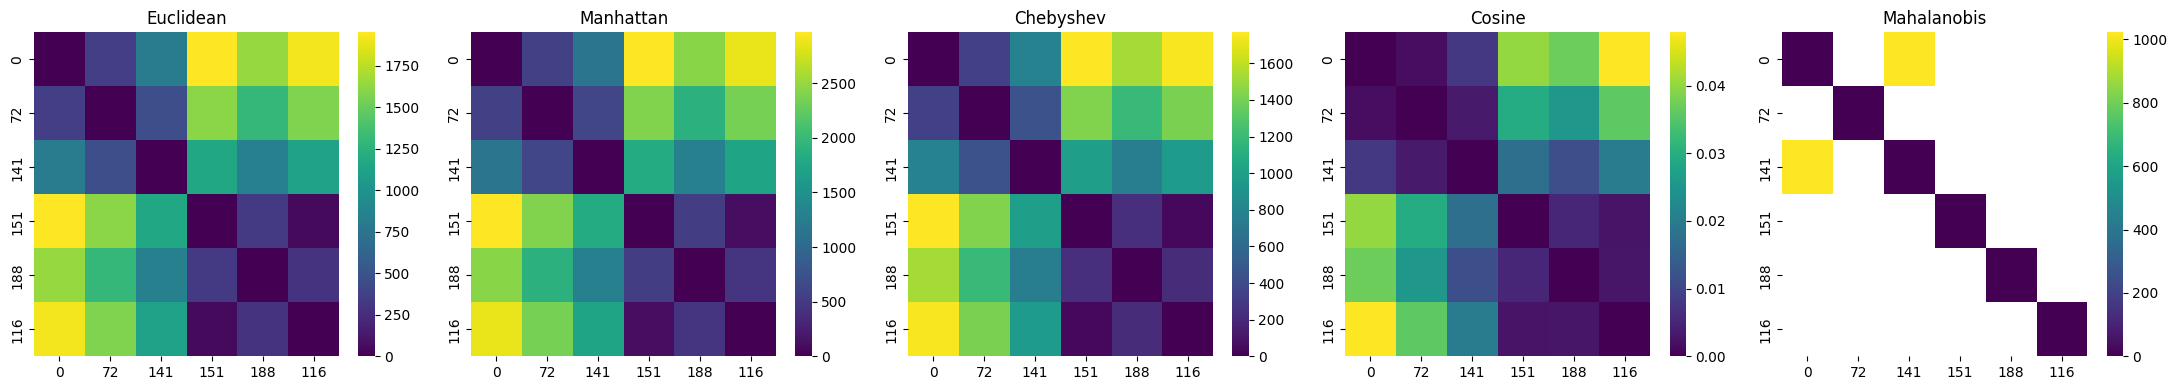

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, mat) in zip(axes, dist_mats.items()):
    sns.heatmap(mat, cmap="viridis", ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()